In [8]:
from pandas_plink import read_plink
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [9]:
prefix = "/storage/plzen4-ntis/home/tadsova/rice_data/base_filtered_v0.7_0.8_10kb_1_0.8_50_1"

In [10]:
# načtení souborů
def snp_matrix(prefix):
    (bim, fam, G) = read_plink(prefix, verbose=False)
    X = G.compute().T.astype(np.float32) # sample x snp
    print("Genotype matrix shape:", X.shape)

    return X, bim, fam

In [11]:
def compute_snp_stats(X, bim):
    count_0 = np.nansum(X == 0, axis=0)
    count_1 = np.nansum(X == 1, axis=0)
    count_2 = np.nansum(X == 2, axis=0)
    n_called  = count_0 + count_1 + count_2

    return pd.DataFrame({
        'snp_id': bim['snp'].values,
        'count_0': count_0.astype(int),
        'count_1': count_1.astype(int),
        'count_2': count_2.astype(int),
        'n_called': n_called.astype(int)
    })

In [12]:
X, bim, fam = snp_matrix(prefix)

Genotype matrix shape: (3024, 404388)


In [13]:
print(X)
print('_' * 40)

[[ 2.  2.  2. ...  2.  2.  2.]
 [ 2.  2.  2. ...  2.  2.  2.]
 [ 2.  2.  2. ...  2.  2.  2.]
 ...
 [ 0.  0.  2. ...  0.  1.  0.]
 [ 0.  0.  2. ...  0. nan  0.]
 [ 2.  2.  2. ...  2.  2.  2.]]
________________________________________


In [14]:
snp_stats = compute_snp_stats(X, bim)

snp_stats.head(10)

,snp_id,count_0,count_1,count_2,n_called
0,1178,179,14,2584,2777
1,1203,642,37,2004,2683
2,1248,68,4,2827,2899
3,1282,30,1,2893,2924
4,1299,222,16,2671,2909
5,1306,42,1,2899,2942
6,1792,35,6,2979,3020
7,5752,217,30,2759,3006
8,6634,136,10,2869,3015
9,11334,487,80,2375,2942


In [21]:
print(np.sum(snp_stats["count_0"]))
print(np.sum(snp_stats["count_1"]))
print(np.sum(snp_stats["count_2"]))

177815730
15459118
975523029


In [20]:
# FAM
print(fam.head()) # no phenotypes, 12 chromozomes

    fid   iid father mother gender trait  i
0  B001  B001      0      0      0    -9  0
1  B002  B002      0      0      0    -9  1
2  B003  B003      0      0      0    -9  2
3  B004  B004      0      0      0    -9  3
4  B005  B005      0      0      0    -9  4


In [10]:
# BIM
print(bim.head())
print('_' * 40)

unique_a0 = bim["a0"].unique()
unique_a1 = bim["a1"].unique()
unique_snp = bim["snp"].unique()
print(f'unikáty a0: {unique_a0}\nunikáty a1: {unique_a1}')
print(f'počet a0: {len(list(bim["a0"]))}')
print(f'počet a1: {len(list(bim["a1"]))}')
print(f'počet unikátních SNP: {bim["snp"].nunique()}')
print('_' * 40)

unique_pairs_count = bim[["a0", "a1"]].drop_duplicates().shape[0]
print(f"Počet unikátních párů a0 a a1: {unique_pairs_count}")

unique_pairs = bim[["a0", "a1"]].drop_duplicates()
print("\nUnikátní páry:")
print(unique_pairs)

pair_counts = bim.groupby(["a0", "a1"]).size().sort_values(ascending=False)
print("\nPočet výskytů každého páru a0 a a1:")
print(pair_counts)

print('_' * 40)
#len(list(bim["pos"])) == len(set(list(bim["pos"])))
print(f'je plný unikátních POS: {bim["pos"].is_unique}')
#len(list(bim["pos"])) - len(set(list(bim["pos"])))
print(f'počet duplikátních POS: {bim["pos"].duplicated().sum()}')

dup_pos = bim[bim["pos"].duplicated(keep=False)]
print(f'počet unikátních duplicitních POS: {dup_pos["pos"].nunique()}')
dup_pos = dup_pos[["chrom", "pos", "snp", "a0", "a1"]].sort_values("pos")
print(dup_pos)

dup_counts = dup_pos["pos"].value_counts().sort_values(ascending=False)
print("\nduplicitní POS:")
print(dup_counts)

dup_distribution = dup_counts.value_counts().sort_index()
print("\npočet duplicit pro POS:")
print(dup_distribution)


  chrom   snp   cm   pos a0 a1  i
0     1  1178  0.0  1178  T  G  0
1     1  1203  0.0  1203  C  T  1
2     1  1248  0.0  1248  A  G  2
3     1  1282  0.0  1282  A  G  3
4     1  1299  0.0  1299  C  T  4
________________________________________
unikáty a0: <StringArray>
['T', 'C', 'A', 'G']
Length: 4, dtype: string
unikáty a1: <StringArray>
['G', 'T', 'A', 'C']
Length: 4, dtype: string
počet a0: 404388
počet a1: 404388
počet unikátních SNP: 404388
________________________________________
Počet unikátních párů a0 a a1: 12

Unikátní páry:
    a0 a1
0    T  G
1    C  T
2    A  G
7    T  A
11   C  A
12   A  C
13   A  T
17   T  C
18   G  A
73   G  C
115  G  T
204  C  G

Počet výskytů každého páru a0 a a1:
a0  a1
T   C     114097
A   G     113964
G   A      39532
C   T      39167
A   T      17505
    C      16498
T   G      15778
    A      15641
C   G       8451
G   C       8447
    T       7760
C   A       7548
dtype: int64
________________________________________
je plný unikátních POS: F

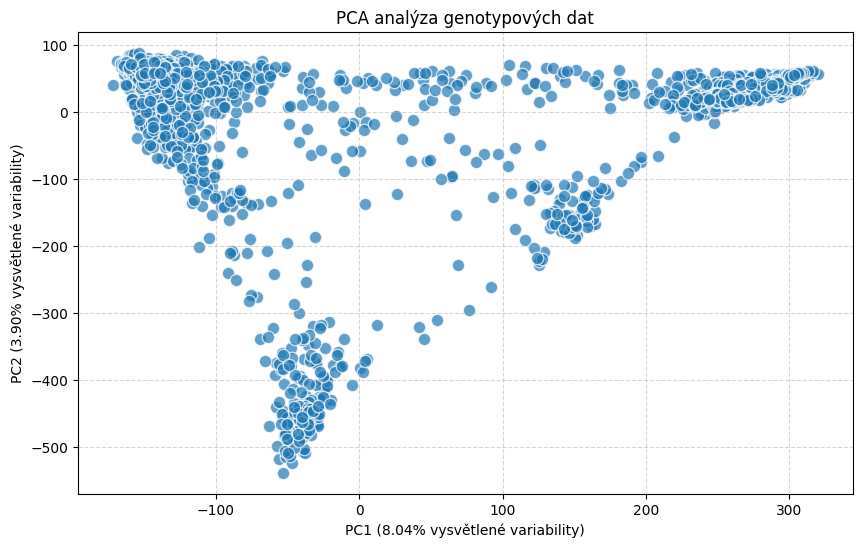

In [11]:
# doplnění dat průměrem
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# standartizace
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# výpočet pca (principal component analysis)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
variance = pca.explained_variance_ratio_ * 100

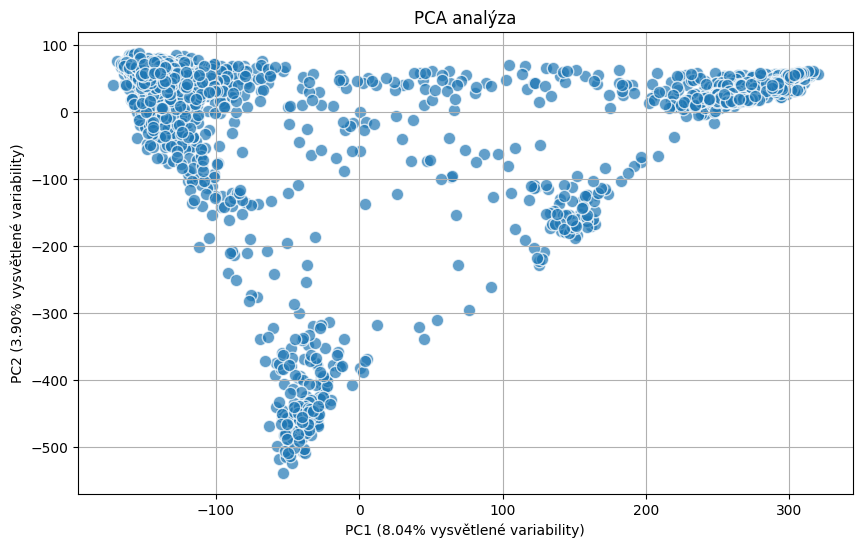

In [13]:
# vizualizace
plt.figure(figsize=(10, 6))
plt.scatter(pcs[:, 0], pcs[:, 1], alpha=0.7, edgecolors='w', s=80)
plt.title('PCA analýza')
plt.xlabel(f'PC1 ({variance[0]:.2f}% vysvětlené variability)')
plt.ylabel(f'PC2 ({variance[1]:.2f}% vysvětlené variability)')
plt.grid(True)
plt.show()